C:\Users\taiga\AppData\Local\Temp\ipykernel_47972\3250967839.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_raw = df['GSR'].fillna(method='ffill').values


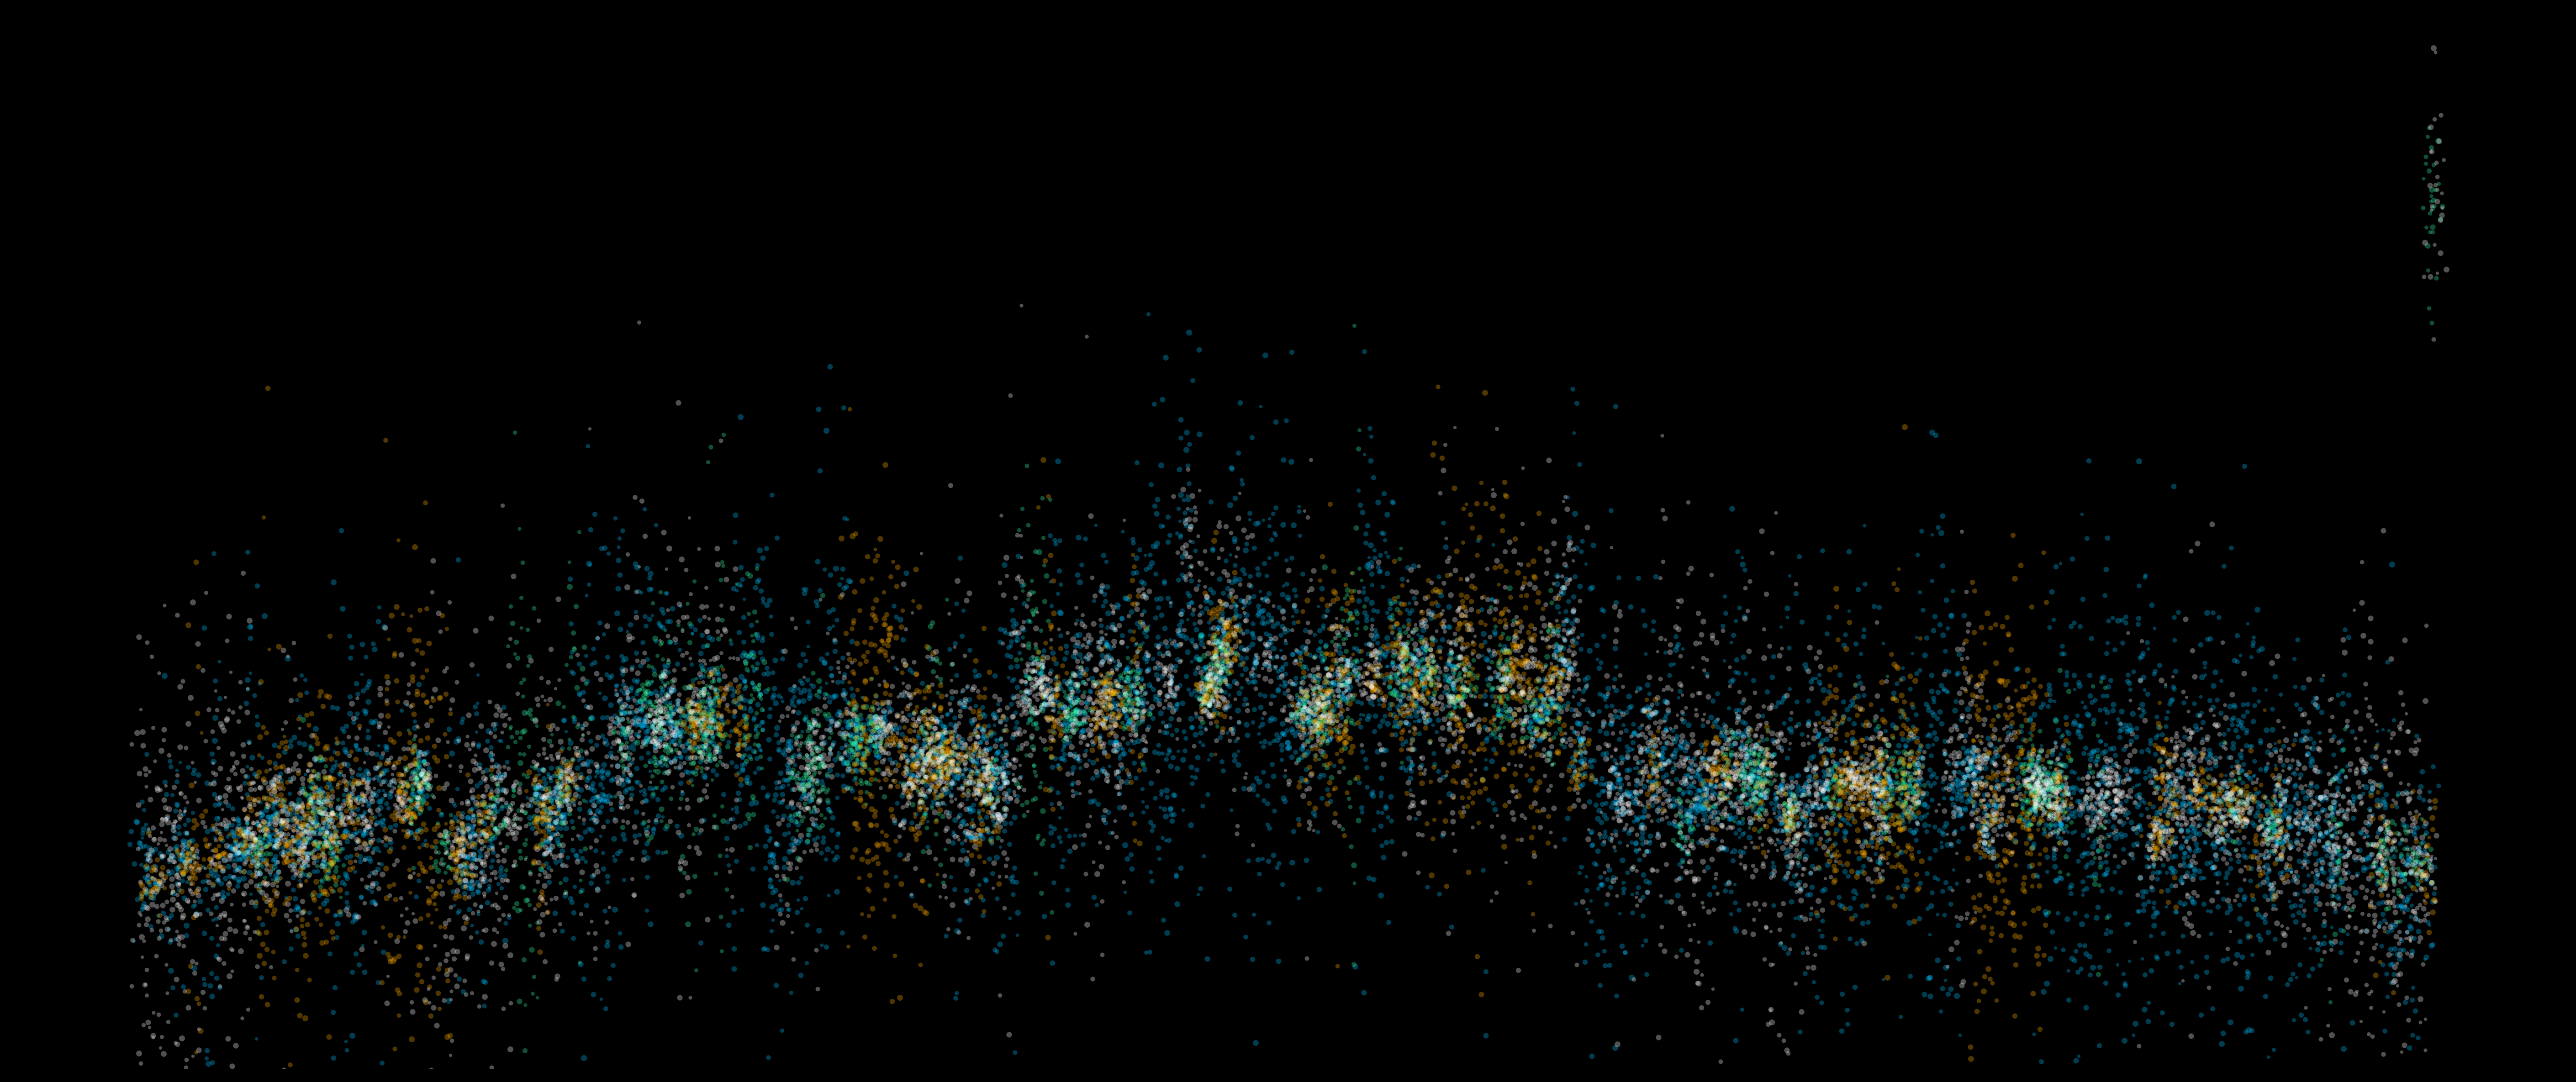

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Loading & Preprocessing
# ---------------------------------------------------------
# Load the UMAP result containing GSR (Galvanic Skin Response) and environmental factors
df = pd.read_csv('002_test_umap_result.csv') 

# Forward-fill missing GSR values and fill factor NaNs with zero
y_raw = df['GSR'].fillna(method='ffill').values
factors = df[['Void', 'Bio', 'Tech', 'Entropy']].fillna(0).values
x_raw = np.arange(len(y_raw))

# ---------------------------------------------------------
# 2. Normalization & Amplitude Scaling
# ---------------------------------------------------------
# Normalize GSR to 0-200 range to emphasize visual fluctuations
y_scaled = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min() + 1e-6) * 200

# ---------------------------------------------------------
# 3. Canvas Setup (Dark Aesthetic)
# ---------------------------------------------------------
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(24, 10), dpi=300)
ax.set_facecolor('#000000')

# High-saturation color palette for environmental factors
# Blue: Void, Green: Bio, Orange: Tech, White: Entropy
f_colors = ['#00BFFF', '#32FFA6', '#FFAB00', '#FFFFFF'] 

# ---------------------------------------------------------
# 4. Particle Generation (Generative Art Approach)
# ---------------------------------------------------------
for i in range(4):
    color = f_colors[i]
    f_val = factors[:, i]
    mask = f_val > 0.05  # Only plot where the factor influence is significant
    
    if not np.any(mask):
        continue

    # Layer 30 iterations of noise to create a "glow" or "particle cloud" effect
    for _ in range(30):
        # Vertical spread is controlled by the factor intensity
        spread = 1.5 + (f_val * 35.0) 
        noise_y = np.random.normal(0, spread, size=len(x_raw))
        noise_x = np.random.normal(0, 0.8, size=len(x_raw))
        
        ax.scatter(
            x_raw[mask] + noise_x[mask], 
            y_scaled[mask] + noise_y[mask], 
            s=np.random.uniform(3, 10), 
            c=color, 
            alpha=0.32, 
            lw=0
        )

# ---------------------------------------------------------
# 5. Aesthetics & Finalization
# ---------------------------------------------------------
# Set plot limits and hide all axes for a clean, artistic look
ax.set_ylim(-50, 250)
ax.set_axis_off()

# Save as high-resolution image with zero padding
plt.savefig(
    'portfolio_art_only.png', 
    dpi=300, 
    bbox_inches='tight', 
    pad_inches=0, 
    facecolor=fig.get_facecolor(), 
    edgecolor='none'
)

plt.show()